# Eksperimen SML — Pima Indians Diabetes

**Nama:** Nazhif Setya Nugroho  
**Kelas:** Membangun Sistem Machine Learning (Dicoding)

Notebook eksperimen untuk dataset **Pima Indians Diabetes** (klasifikasi biner: memprediksi apakah pasien mengidap diabetes). Alur: **Data Loading → EDA → Data Preprocessing**, kemudian menyimpan dataset yang sudah siap dilatih.

## Import Library

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Library siap.")

Library siap.


## 1. Data Loading

Memuat dataset mentah (`diabetes_raw.csv`) dan melihat struktur awalnya.

In [2]:
df = pd.read_csv("../diabetes_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Exploratory Data Analysis (EDA)

Memahami distribusi, statistik ringkas, keseimbangan kelas, korelasi, dan mendeteksi missing value (baik yang eksplisit maupun tersembunyi).

### 2.1 Statistik Deskriptif

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.2 Distribusi Kelas Target

Outcome
0    500
1    268
Name: count, dtype: int64

Proporsi kelas:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


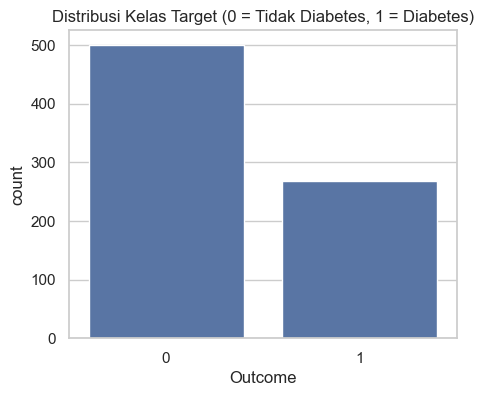

In [5]:
print(df["Outcome"].value_counts())
print("\nProporsi kelas:")
print(df["Outcome"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Distribusi Kelas Target (0 = Tidak Diabetes, 1 = Diabetes)")
plt.show()

### 2.3 Deteksi Missing Value

Selain NaN eksplisit, beberapa kolom medis memiliki nilai `0` yang tidak masuk akal (mis. `Glucose`, `BloodPressure`, `BMI` = 0). Nilai `0` ini sebenarnya adalah **missing value tersembunyi** yang harus ditangani saat preprocessing.

In [6]:
print("Missing values eksplisit (NaN):")
print(df.isnull().sum())

zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nJumlah nilai 0 (missing tersembunyi) per kolom:")
print((df[zero_cols] == 0).sum())

Missing values eksplisit (NaN):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah nilai 0 (missing tersembunyi) per kolom:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### 2.4 Distribusi Setiap Fitur

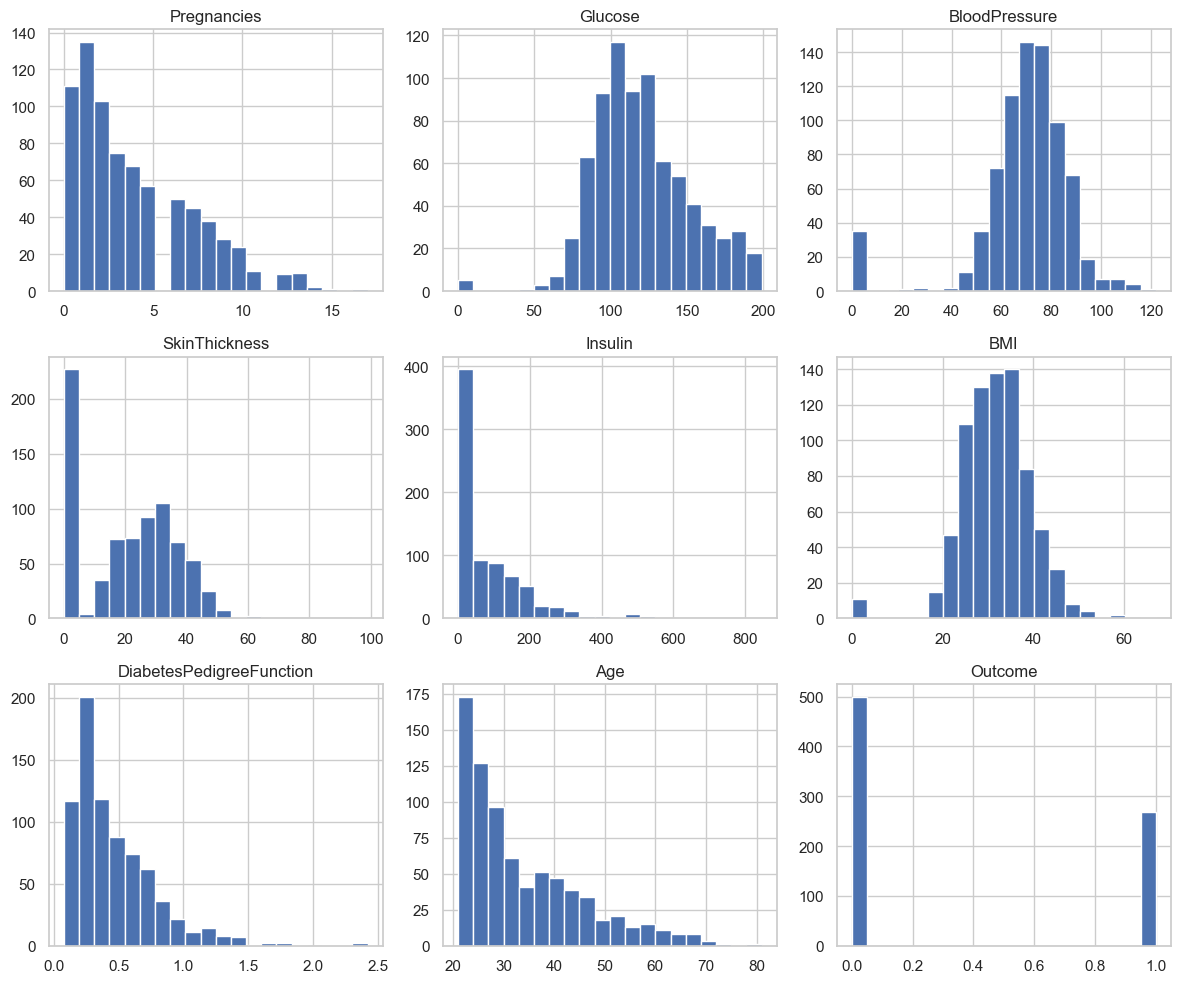

In [7]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

### 2.5 Korelasi Antar Fitur

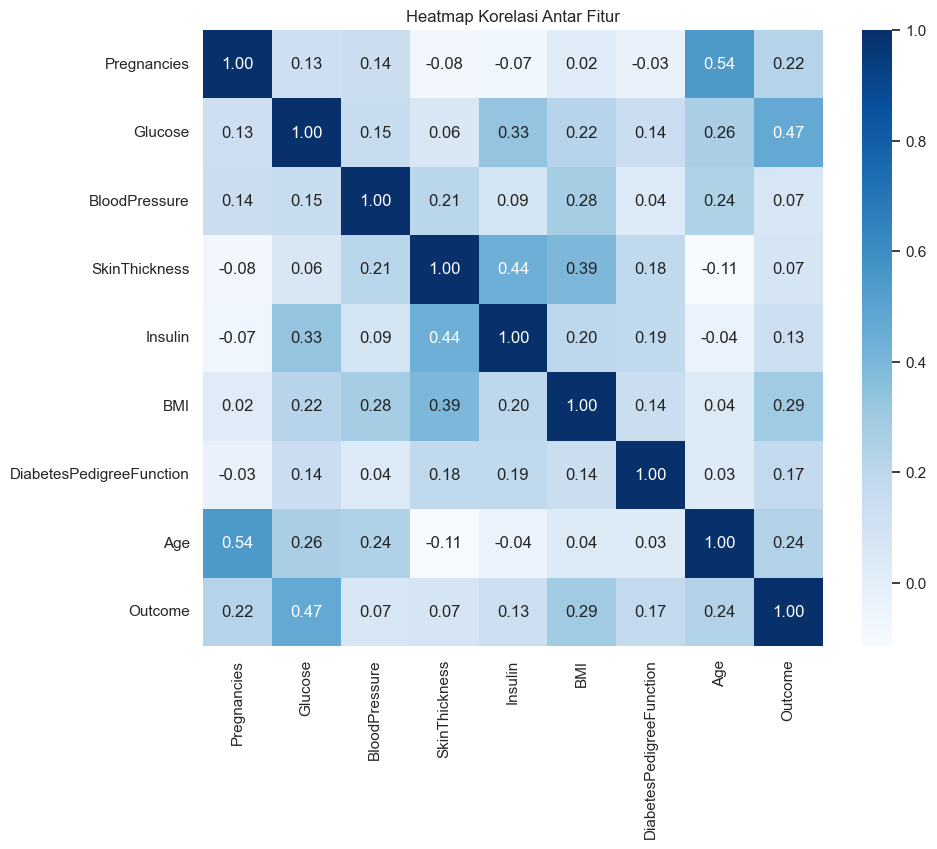

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

### 2.6 Deteksi Outlier (Boxplot)

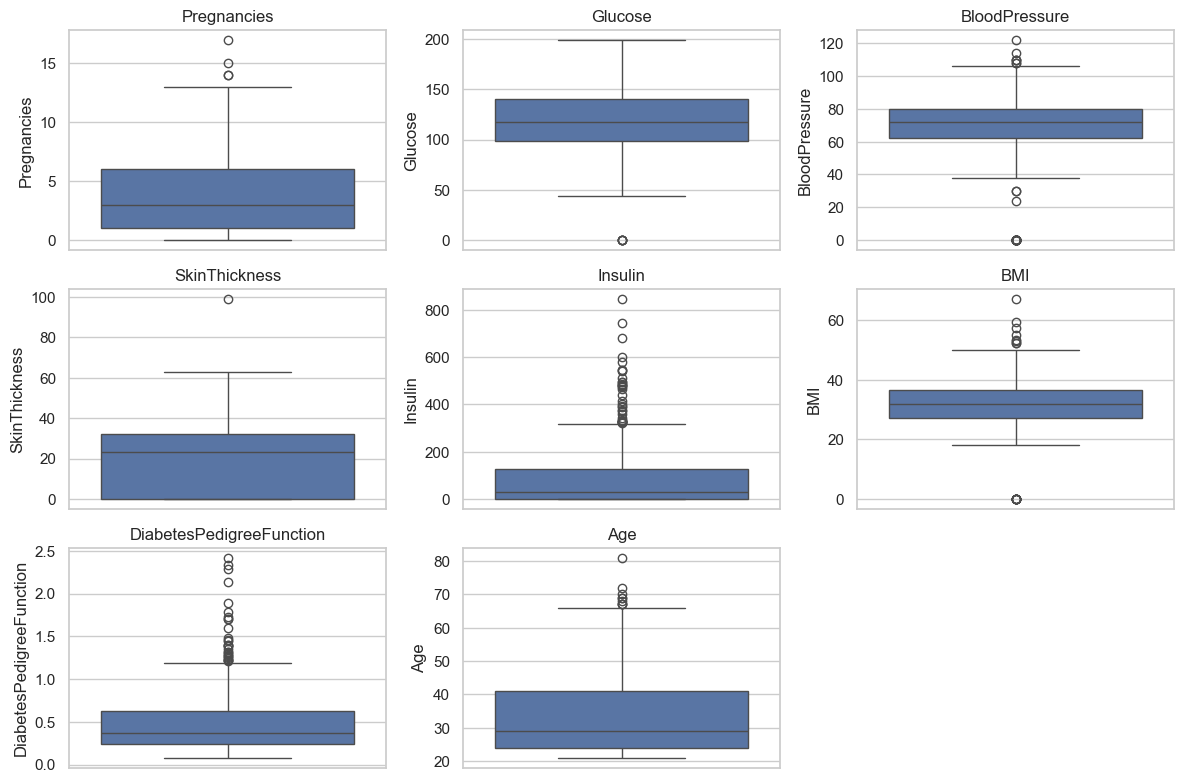

In [9]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

Langkah-langkah:
1. Ganti nilai `0` tersembunyi pada kolom medis menjadi `NaN`.
2. Imputasi missing value dengan **median** (robust terhadap outlier).
3. **Standardisasi** fitur dengan `StandardScaler`.
4. Simpan dataset yang sudah siap dilatih ke `diabetes_preprocessing.csv`.

### 3.1 Ganti Nilai 0 Tersembunyi → NaN

In [10]:
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)
print("Missing value setelah 0 -> NaN:")
print(df_clean.isnull().sum())

Missing value setelah 0 -> NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### 3.2 Imputasi Median

In [11]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print("Total missing setelah imputasi:", int(X_imputed.isnull().sum().sum()))
X_imputed.head()

Total missing setelah imputasi: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


### 3.3 Standardisasi Fitur

In [12]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)
X_scaled.describe().round(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.142,-2.553,-4.003,-2.516,-1.467,-2.075,-1.190,-1.042
25%,-0.845,-0.720,-0.694,-0.468,-0.222,-0.721,-0.689,-0.786
50%,-0.251,-0.153,-0.032,-0.012,-0.182,-0.023,-0.300,-0.361
75%,0.640,0.611,0.630,0.329,-0.155,0.603,0.466,0.660
max,3.907,2.543,4.104,7.955,8.170,5.042,5.884,4.064


### 3.4 Simpan Dataset Siap Latih

In [13]:
df_preprocessed = X_scaled.copy()
df_preprocessed["Outcome"] = y.values
df_preprocessed.to_csv("diabetes_preprocessing.csv", index=False)
print("Tersimpan: diabetes_preprocessing.csv", df_preprocessed.shape)
df_preprocessed.head()

Tersimpan: diabetes_preprocessing.csv (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,1


### 3.5 Verifikasi: Siap untuk Train/Test Split

In [14]:
X_final = df_preprocessed.drop(columns=["Outcome"])
y_final = df_preprocessed["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Distribusi kelas train:\n", y_train.value_counts(normalize=True).round(3))

Train: (614, 8) | Test: (154, 8)
Distribusi kelas train:
 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## Kesimpulan

- Dataset **768 baris × 9 kolom**, target `Outcome` sedikit tidak seimbang (~65% : 35%).
- Ditemukan **missing value tersembunyi** berupa nilai `0` pada kolom medis, ditangani lewat imputasi median.
- Seluruh fitur numerik distandardisasi dengan `StandardScaler`.
- Output `diabetes_preprocessing.csv` sudah **siap dilatih** dan menjadi input untuk tahap pemodelan (Kriteria 2).